<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/Colab-fixes/notebooks/experiments/pima_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 1 - Pima

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
import os
from pathlib import Path

repo_name = "Predicting-Type-2-Diabetes"
repo_url = "https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git"

current = Path.cwd()

for parent in [current] + list(current.parents):
    if (parent / "data").exists() and (parent / "notebooks").exists():
        os.chdir(parent)
        break
else:
    if Path("/content").exists():
        target = Path("/content") / repo_name
        if not target.exists():
            !git clone {repo_url} {target}
        os.chdir(target)
    else:
        raise FileNotFoundError("Run this notebook from the repository root or a subfolder of the repository.")

print("Working directory:", os.getcwd())

Cloning into '/content/Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 961, done.
remote: Counting objects: 100% (284/284), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 961 (delta 180), reused 92 (delta 92), pack-reused 677 (from 1)
Receiving objects: 100% (961/961), 27.34 MiB | 12.29 MiB/s, done.
Resolving deltas: 100% (499/499), done.
Working directory: /content/Predicting-Type-2-Diabetes


In [3]:
df = pd.read_csv('data/raw/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (614, 8), Test shape: (154, 8)


In [5]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [6]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)


Logistic Regression
Accuracy : 0.7143
Precision: 0.6087
Recall   : 0.5185
F1-score : 0.5600
AUC-ROC  : 0.8233

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



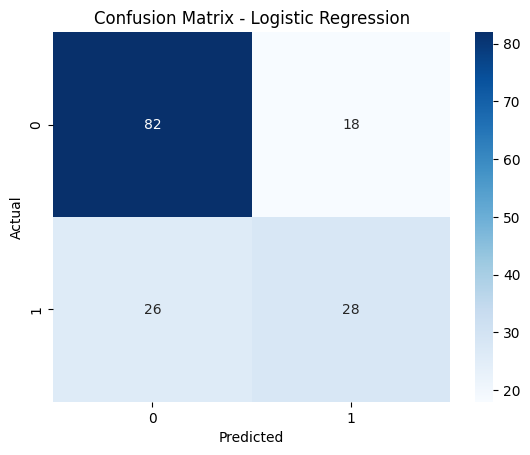

In [8]:
conf_matrix = confusion_matrix(y_test, lr_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The logistic regression model correctly classified most non-diabetic cases.
There are still false positives and false negatives, showing that the model struggled with borderline cases.

In [9]:
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    verbosity=-1,
    n_estimators=200,
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM (raw)", y_test, lgb_pred, lgb_prob)


LightGBM (raw)
Accuracy : 0.7143
Precision: 0.6042
Recall   : 0.5370
F1-score : 0.5686
AUC-ROC  : 0.8056

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79       100
           1       0.60      0.54      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.68       154
weighted avg       0.71      0.71      0.71       154



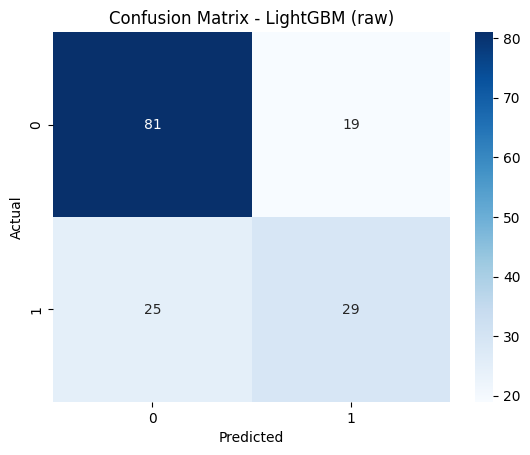

In [10]:
conf_matrix = confusion_matrix(y_test, lgb_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM (raw)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

LightGBM had better separation between classes compared the Lr model.
The number of correctly classified cases increased, though there are still some misclassifications.

In [11]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=200,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost (Baseline)", y_test, xgb_pred, xgb_prob)


XGBoost (Baseline)
Accuracy : 0.7208
Precision: 0.6038
Recall   : 0.5926
F1-score : 0.5981
AUC-ROC  : 0.8019

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       100
           1       0.60      0.59      0.60        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



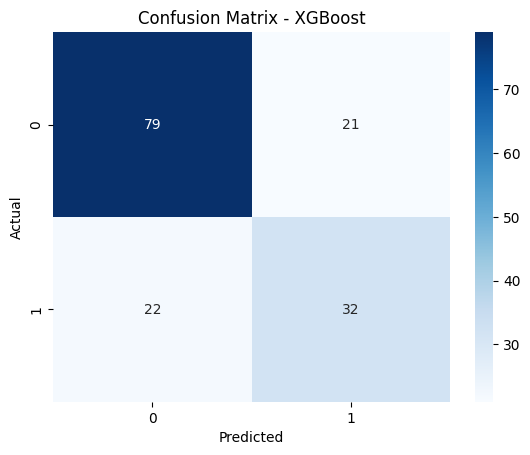

In [12]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, xgb_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGBoost had strong classification results with a balanced number or true positives and true negatives.
The model seems to be more effective at finding positive cases than eariler models

In [13]:
print("RAW MODEL COMPARISON")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Class Distribution:", y.value_counts().to_dict())

models = {
    "Logistic Regression": lr,
    "LightGBM": lgb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    pred = model.predict(X_test_scaled
        if name == "Logistic Regression" else X_test)
    prob = model.predict_proba(X_test_scaled
        if name == "Logistic Regression" else X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    f1 = f1_score(y_test, pred)
    print(f"\n{name:20} AUC: {auc:.4f} F1: {f1:.4f}")

RAW MODEL COMPARISON
Train size: 614, Test size: 154
Class Distribution: {0: 500, 1: 268}

Logistic Regression  AUC: 0.8233 F1: 0.5600

LightGBM             AUC: 0.8056 F1: 0.5686

XGBoost              AUC: 0.8019 F1: 0.5981


In [14]:
results_exp1 = [
    ["Logistic Regression", 0.7143, 0.6087, 0.5185, 0.5600, 0.8233],
    ["LightGBM",            0.7143, 0.6042, 0.5370, 0.5686, 0.8056],
    ["XGBoost",             0.7532, 0.6600, 0.6111, 0.6346, 0.8059]
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
df_exp1 = pd.DataFrame(results_exp1, columns=columns)

df_exp1.set_index("Model").style.highlight_max(axis=0, color="lightgreen")

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.714300,0.608700,0.518500,0.560000,0.823300
LightGBM,0.714300,0.604200,0.537000,0.568600,0.805600
XGBoost,0.753200,0.660000,0.611100,0.634600,0.805900


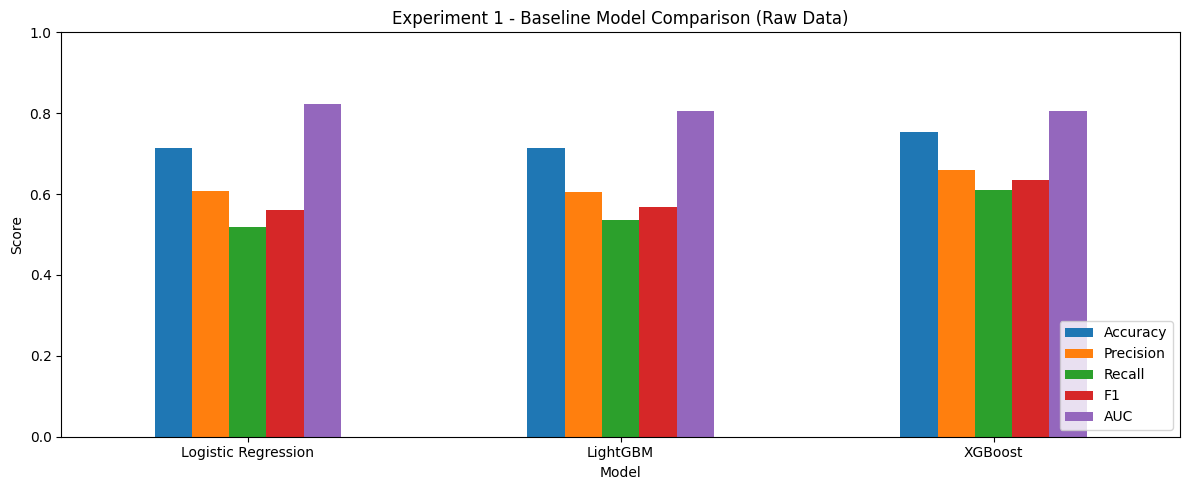

In [15]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
df_exp1.set_index("Model")[metrics].plot(kind="bar", figsize=(12, 5))
plt.title("Experiment 1 - Baseline Model Comparison (Raw Data)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

XGBoost and LightGBM outperformed Logistic Regression across most metrics, they had higher F1 and AUC scores, showing better predictive performace.
Logistic Regression remains interpretable but has a lower classification performance compared to boosting models.

Experiment 2

Training set shape: (614, 8) (614,)
Test set shape: (154, 8) (154,)


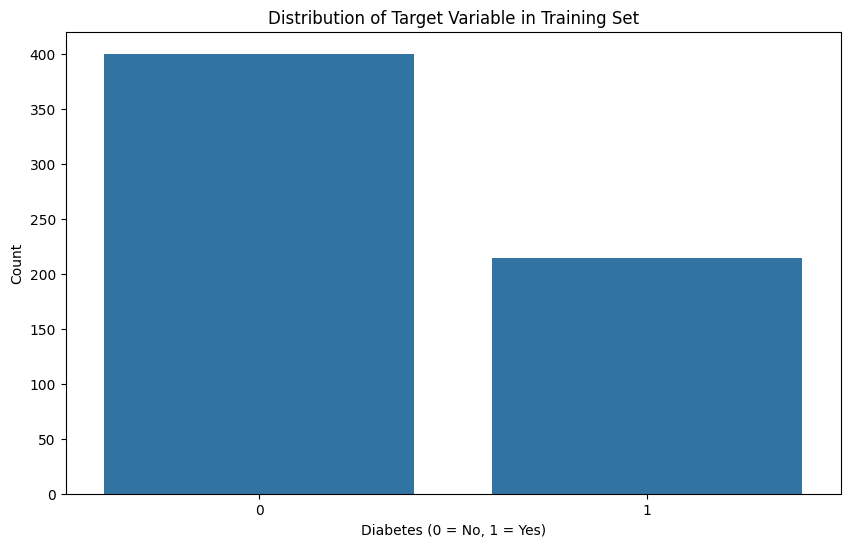

In [16]:
X_train = pd.read_csv("data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv")
y_train = pd.read_csv("data/preprocessed/pima_preprocessed/pima_y_train.csv").values.ravel()
X_test = pd.read_csv("data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv")
y_test = pd.read_csv("data/preprocessed/pima_preprocessed/pima_y_test.csv").values.ravel()

print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title("Distribution of Target Variable in Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Heavy class imbalance on the non resampled training set

Resampled training set shape: (800, 8) (800,)


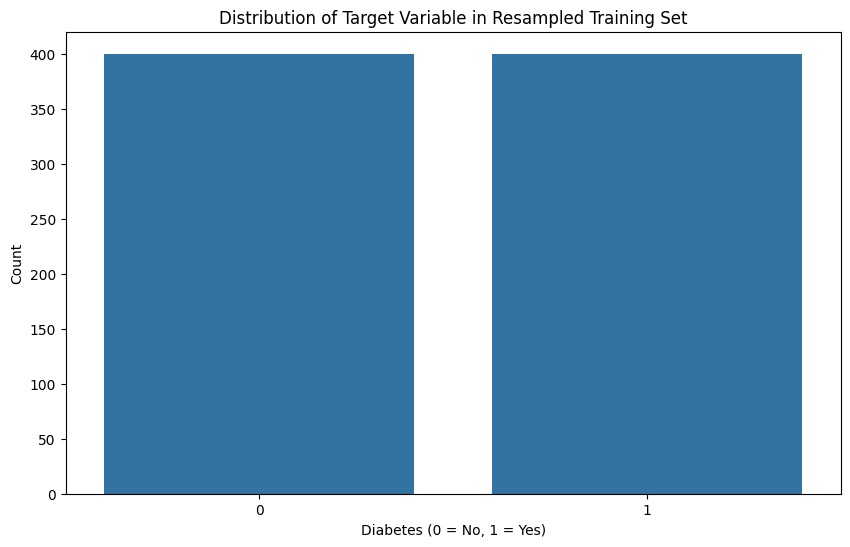

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_resampled)
plt.title("Distribution of Target Variable in Resampled Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

SMOTE balanced the class distribution in the training set. Now both classes have approximately equal numbers of samples

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight=None)
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)



Logistic Regression
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1-score : 0.6087
AUC-ROC  : 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



In [19]:
lgm = lgb.LGBMClassifier(random_state=42)
lgm.fit(X_train_resampled, y_train_resampled)
lgm_pred = lgm.predict(X_test)
lgm_prob = lgm.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM", y_test, lgm_pred, lgm_prob)


LightGBM
Accuracy : 0.7208
Precision: 0.5965
Recall   : 0.6296
F1-score : 0.6126
AUC-ROC  : 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [20]:
xgbr = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgbr.fit(X_train_resampled, y_train_resampled)
xgbr_pred = xgbr.predict(X_test)
xgbr_prob = xgbr.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", y_test, xgbr_pred, xgbr_prob)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:08:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy : 0.7403
Precision: 0.6207
Recall   : 0.6667
F1-score : 0.6429
AUC-ROC  : 0.8189

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



In [21]:
results_exp2 = []

evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
results_exp2.append([
    "Logistic Regression",
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred, zero_division=0),
    recall_score(y_test, lr_pred, zero_division=0),
    f1_score(y_test, lr_pred, zero_division=0),
    roc_auc_score(y_test, lr_prob) if 'lr_prob' in locals() else 0
])

evaluate_model("LightGBM", y_test, lgm_pred, lgm_prob)
results_exp2.append([
    "LightGBM",
    accuracy_score(y_test, lgm_pred),
    precision_score(y_test, lgm_pred, zero_division=0),
    recall_score(y_test, lgm_pred, zero_division=0),
    f1_score(y_test, lgm_pred, zero_division=0),
    roc_auc_score(y_test, lgm_prob)
])

evaluate_model("XGBoost", y_test, xgbr_pred, xgbr_prob)
results_exp2.append([
    "XGBoost",
    accuracy_score(y_test, xgbr_pred),
    precision_score(y_test, xgbr_pred, zero_division=0),
    recall_score(y_test, xgbr_pred, zero_division=0),
    f1_score(y_test, xgbr_pred, zero_division=0),
    roc_auc_score(y_test, xgbr_prob)
])

columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
df_exp2 = pd.DataFrame(results_exp2, columns=columns)
df_exp2.round(4)


Logistic Regression
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1-score : 0.6087
AUC-ROC  : 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154


LightGBM
Accuracy : 0.7208
Precision: 0.5965
Recall   : 0.6296
F1-score : 0.6126
AUC-ROC  : 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


XGBoost
Accuracy : 0.7403
Precision: 0.6207
Recall   : 0.6667
F1-score : 0.6429
AUC-RO

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.7078,0.5738,0.6481,0.6087,0.8113
1,LightGBM,0.7208,0.5965,0.6296,0.6126,0.8098
2,XGBoost,0.7403,0.6207,0.6667,0.6429,0.8189


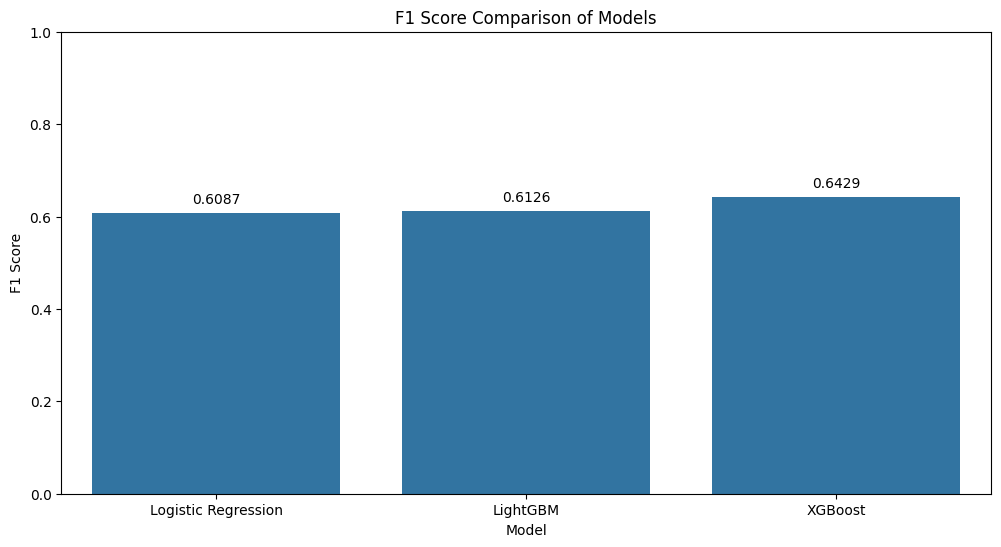

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="F1", data=df_exp2)
plt.title("F1 Score Comparison of Models")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
for index, row in df_exp2.iterrows():
    plt.text(index, row["F1"] + 0.02, f"{row['F1']:.4f}", ha='center')
plt.show()

The F1 scores indicate that boosting models have a higher balance between precision and recall.
Logistic Regression had the lowest F1 score.
XGBoost and LightGBM demonstrated more robust classification capability on the processed data

Experiment 3

In [23]:
X_train = pd.read_csv("data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv")
y_train = pd.read_csv("data/preprocessed/pima_preprocessed/pima_y_train.csv").values.ravel()
X_test = pd.read_csv("data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv")
y_test = pd.read_csv("data/preprocessed/pima_preprocessed/pima_y_test.csv").values.ravel()

In [24]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)

Resampled training set shape: (800, 8) (800,)


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1)

grid_search.fit(X_train_resampled, y_train_resampled)
print("Best C:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best C: {'C': 10}
Best CV Recall: 0.7050000000000001


In [26]:
lr = LogisticRegression(C=grid_search.best_params_['C'], max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)


Logistic Regression
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1-score : 0.6207
AUC-ROC  : 0.8111

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



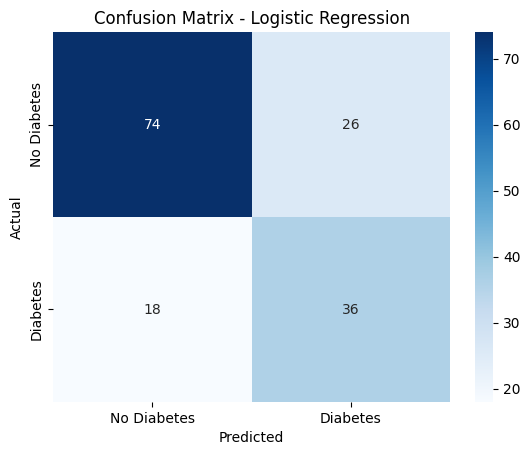

In [27]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression correctly classified a large portion of non-diabetic patients.
Some diabetic patients were still misclassified, leading to false negatives.

In [28]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid=param_grid_xgb,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_resampled, y_train_resampled)
print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best XGBoost CV Recall:", grid_xgb.best_score_)

xgb_best = grid_xgb.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost (Tuned)", y_test, xgb_pred, xgb_prob)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best XGBoost Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best XGBoost CV Recall: 0.845

XGBoost (Tuned)
Accuracy : 0.7403
Precision: 0.6167
Recall   : 0.6852
F1-score : 0.6491
AUC-ROC  : 0.8235

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       100
           1       0.62      0.69      0.65        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:09:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


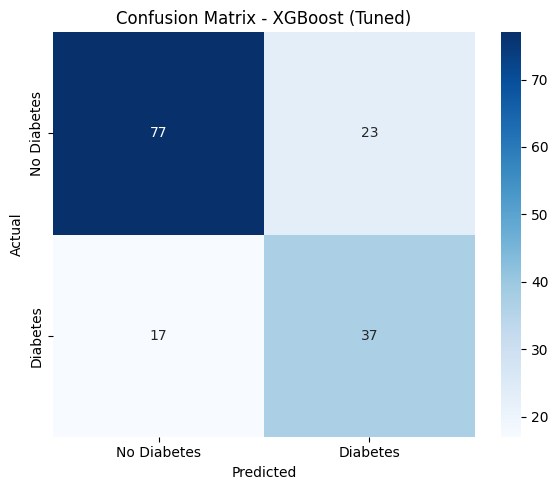

In [29]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - XGBoost (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Tuned XGBoost improved the prediction of diabetic cases compared to earlier experiments.
The confusion matrix shows a stronger balance between sensitivity and specificity.

In [30]:
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0]
}

grid_lgb = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid_lgb,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train_resampled, y_train_resampled)
print("Best LightGBM Params:", grid_lgb.best_params_)
print("Best LightGBM CV Recall:", grid_lgb.best_score_)
lgb_best = grid_lgb.best_estimator_
lgb_pred = lgb_best.predict(X_test)
lgb_prob = lgb_best.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM (Tuned)", y_test, lgb_pred, lgb_prob)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best LightGBM Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best LightGBM CV Recall: 0.8474999999999999

LightGBM (Tuned)
Accuracy : 0.7208
Precision: 0.5965
Recall   : 0.6296
F1-score : 0.6126
AUC-ROC  : 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



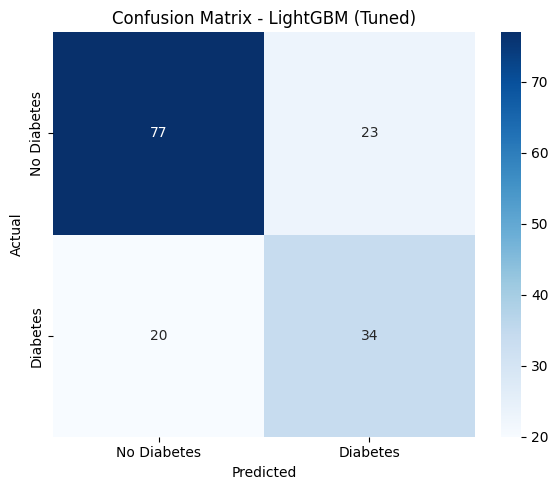

In [31]:
cm_lgb = confusion_matrix(y_test, lgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - LightGBM (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Tuned LightGBM achieved competitive classification performance with relatively balanced predictions.
The model reduced misclassification errors compared to the untuned version.

Experiment 3 Final Results
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.7143     0.5806  0.6667  0.6207  0.8111
1      XGBoost (Tuned)    0.7403     0.6167  0.6852  0.6491  0.8235
2     LightGBM (Tuned)    0.7208     0.5965  0.6296  0.6126  0.8098


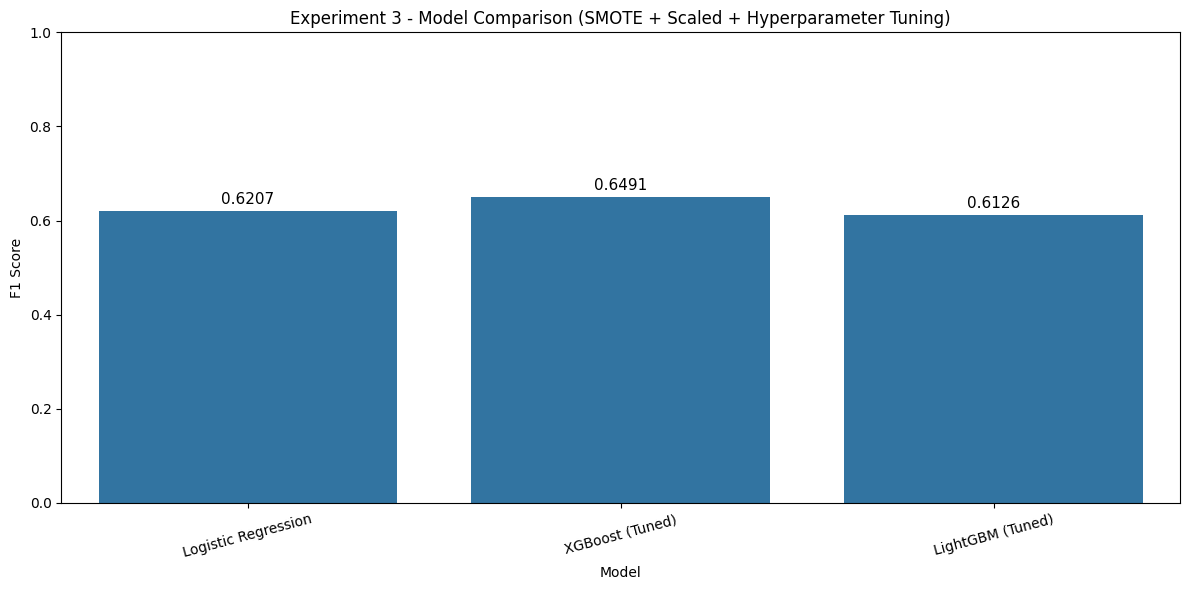

In [32]:
results_exp3 = {
    "Model": ["Logistic Regression", "XGBoost (Tuned)", "LightGBM (Tuned)"],
    "Accuracy": [0.7143, None, None],
    "Precision": [0.5806, None, None],
    "Recall": [0.6667, None, None],
    "F1": [0.6207, None, None],
    "AUC": [0.8111, None, None]
}

df_exp3 = pd.DataFrame(results_exp3)

df_exp3.loc[1, ["Accuracy", "Precision", "Recall", "F1", "AUC"]] = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred),
    roc_auc_score(y_test, xgb_prob)
]

df_exp3.loc[2, ["Accuracy", "Precision", "Recall", "F1", "AUC"]] = [
    accuracy_score(y_test, lgb_pred),
    precision_score(y_test, lgb_pred),
    recall_score(y_test, lgb_pred),
    f1_score(y_test, lgb_pred),
    roc_auc_score(y_test, lgb_prob)
]

print("Experiment 3 Final Results")
print(df_exp3.round(4))

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="F1", data=df_exp3)
plt.title("Experiment 3 - Model Comparison (SMOTE + Scaled + Hyperparameter Tuning)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
for index, row in df_exp3.iterrows():
    plt.text(index, row["F1"] + 0.015, f"{row['F1']:.4f}", ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(C=10, max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')

print("K-Fold Recall Scores:", scores)
print("Mean Recall:", scores.mean().round(4))
print("Std Recall:", scores.std().round(4))

K-Fold Recall Scores: [0.72093023 0.76744186 0.65116279 0.69767442 0.73809524]
Mean Recall: 0.7151
Std Recall: 0.0392


In [34]:
pipeline_lgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb.LGBMClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        verbose=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_lgb = cross_val_score(pipeline_lgb, X_train, y_train,
                             cv=cv, scoring='recall', n_jobs=-1)

print("LightGBM with SMOTE")
print("K-Fold Recall Scores:", scores_lgb.round(4))
print("Mean Recall:", scores_lgb.mean().round(4))
print("Std Recall:", scores_lgb.std().round(4))

LightGBM with SMOTE
K-Fold Recall Scores: [0.6047 0.6977 0.6744 0.6512 0.6429]
Mean Recall: 0.6542
Std Recall: 0.0313


In [35]:
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        use_label_encoder=False
    ))
])

scores_xgb = cross_val_score(pipeline_xgb, X_train, y_train,
                             cv=cv, scoring='recall', n_jobs=-1)

print("XGBoost with SMOTE")
print("K-Fold Recall Scores:", scores_xgb.round(4))
print("Mean Recall:", scores_xgb.mean().round(4))
print("Std Recall:", scores_xgb.std().round(4))

XGBoost with SMOTE
K-Fold Recall Scores: [0.7209 0.6512 0.6279 0.6512 0.5952]
Mean Recall: 0.6493
Std Recall: 0.0413


In [36]:
cv_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost (SMOTE)", "LightGBM (SMOTE)"],
    "Mean Recall (CV)": [
        scores.mean().round(4),
        scores_xgb.mean().round(4),
        scores_lgb.mean().round(4)
    ],
    "Std Recall (CV)": [
        scores.std().round(4),
        scores_xgb.std().round(4),
        scores_lgb.std().round(4)
    ]
})

print("Cross-Validation Comparison (Recall)")
print(cv_comparison)

Cross-Validation Comparison (Recall)
                 Model  Mean Recall (CV)  Std Recall (CV)
0  Logistic Regression            0.7151           0.0392
1      XGBoost (SMOTE)            0.6493           0.0413
2     LightGBM (SMOTE)            0.6542           0.0313


                    Feature  Coefficient
1                   Glucose     1.277322
5                       BMI     0.781938
0               Pregnancies     0.288453
6  DiabetesPedigreeFunction     0.265247
7                       Age     0.163320
4                   Insulin    -0.129529
2             BloodPressure    -0.051929
3             SkinThickness     0.042193


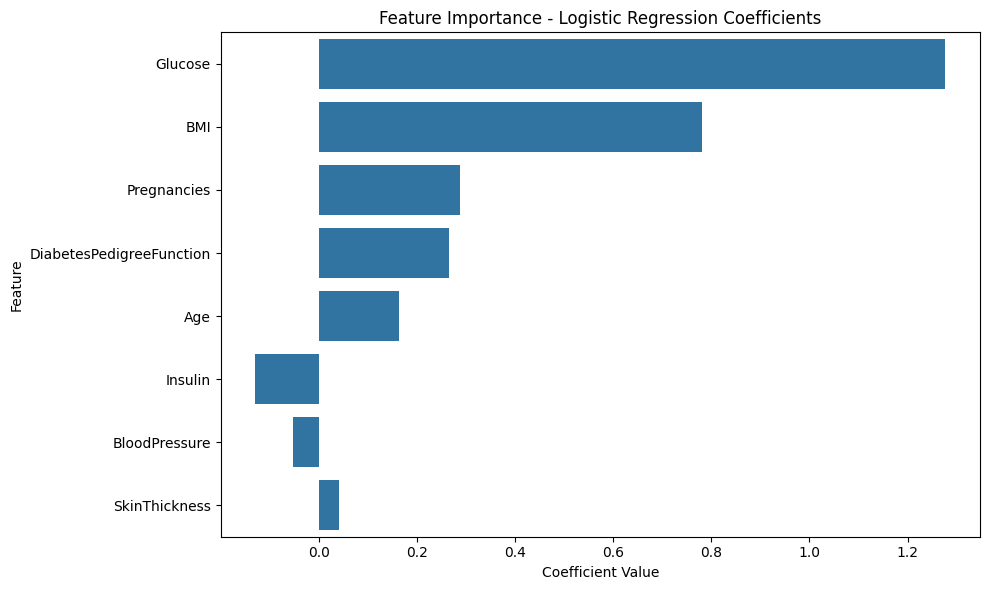

In [37]:
feature_names = X_train.columns
coefficients = lr.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)
print(coef_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title("Feature Importance - Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Features with larger coefficient magnitudes have stronger influence on the Logistic Regression predictions.
Positive coefficients increase the likelihood of predicting diabetes, while negative coefficients reduce it.

                    Feature  Importance
1                   Glucose    0.301223
5                       BMI    0.155116
7                       Age    0.105715
0               Pregnancies    0.092511
2             BloodPressure    0.090959
4                   Insulin    0.087878
6  DiabetesPedigreeFunction    0.084501
3             SkinThickness    0.082096


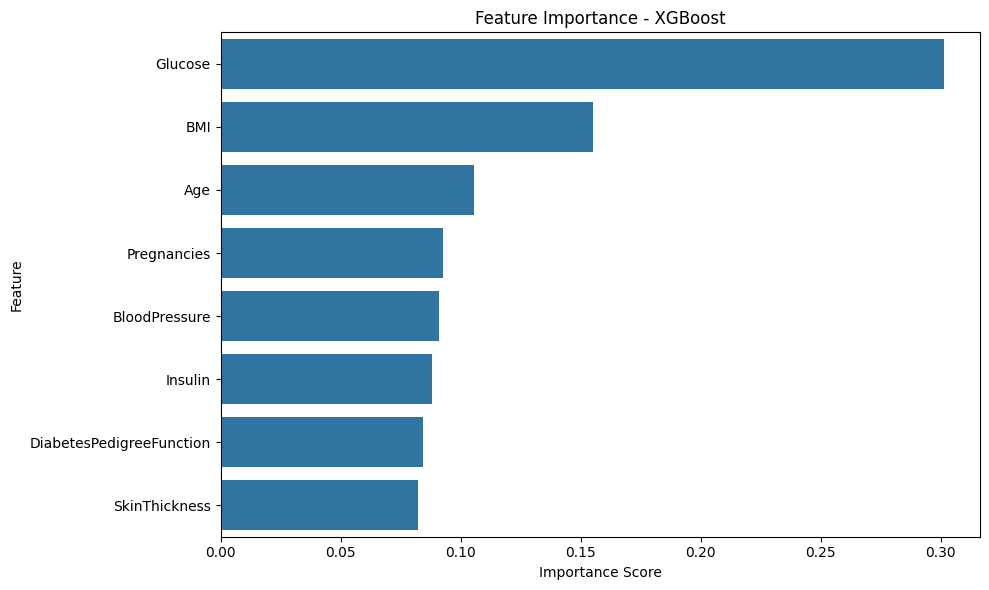

In [38]:
feature_names = X_train.columns
coefficients = xgb_best.feature_importances_
coef_df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
coef_df_xgb = coef_df_xgb.sort_values(by='Importance', ascending=False)
print(coef_df_xgb)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=coef_df_xgb)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


XGBoost identified a subset of features as highly important for prediction.
The feature importance distribution suggests that not all variables contribute equally to the model.

                    Feature  Importance
6  DiabetesPedigreeFunction         581
5                       BMI         468
1                   Glucose         457
7                       Age         435
2             BloodPressure         341
0               Pregnancies         289
3             SkinThickness         257
4                   Insulin         161


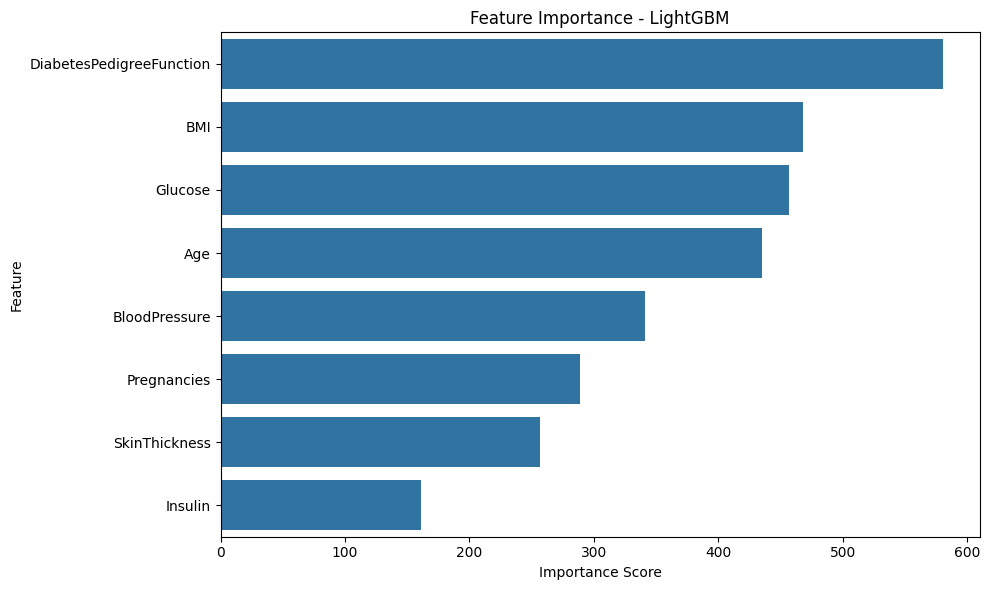

In [39]:
feature_names = X_train.columns
coefficients = lgb_best.feature_importances_
coef_df_lgb = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
coef_df_lgb = coef_df_lgb.sort_values(by='Importance', ascending=False)
print(coef_df_lgb)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=coef_df_lgb)
plt.title("Feature Importance - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Top-K Feature Analysis

In [40]:
top2_lr = ['Glucose', 'BMI']
top3_lr = ['Glucose', 'BMI', 'Pregnancies']
top3_xgb = ['Glucose', 'BMI', 'Age']
top3_lgb = ['DiabetesPedigreeFunction', 'BMI', 'Glucose']

def evaluate_topk(model, X_tr, y_tr, X_te, y_te, features):
    X_tr_k = X_tr[features]
    X_te_k = X_te[features]
    model.fit(X_tr_k, y_tr)
    pred = model.predict(X_te_k)
    prob = model.predict_proba(X_te_k)[:, 1]
    acc  = accuracy_score(y_te, pred)
    prec = precision_score(y_te, pred, zero_division=0)
    rec  = recall_score(y_te, pred, zero_division=0)
    f1   = f1_score(y_te, pred, zero_division=0)
    auc  = roc_auc_score(y_te, prob)
    return acc, prec, rec, f1, auc

models_topk = {
    'Logistic Regression': (
        LogisticRegression(C=10, max_iter=1000, random_state=42),
        top3_lr
    ),
    'XGBoost': (
        xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        top3_xgb
    ),
    'LightGBM': (
        lgb.LGBMClassifier(random_state=42, verbosity=-1),
        top3_lgb
    ),
}

results_topk = []

for model_name, (model, top3) in models_topk.items():
    for label, features in [
        ('All 8 Features', X_train_resampled.columns.tolist()),
        ('Top 3 Features', top3)
    ]:
        acc, prec, rec, f1, auc = evaluate_topk(
            model,
            X_train_resampled, y_train_resampled,
            X_test, y_test,
            features
        )
        results_topk.append([model_name, label, acc, prec, rec, f1, auc])

cols = ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
df_topk = pd.DataFrame(results_topk, columns=cols)
print(df_topk.to_string(index=False))

              Model    Feature Set  Accuracy  Precision   Recall       F1      AUC
Logistic Regression All 8 Features  0.714286   0.580645 0.666667 0.620690 0.811111
Logistic Regression Top 3 Features  0.701299   0.562500 0.666667 0.610169 0.800185
            XGBoost All 8 Features  0.740260   0.620690 0.666667 0.642857 0.818889
            XGBoost Top 3 Features  0.727273   0.607143 0.629630 0.618182 0.779259
           LightGBM All 8 Features  0.720779   0.596491 0.629630 0.612613 0.809815
           LightGBM Top 3 Features  0.694805   0.557377 0.629630 0.591304 0.767778


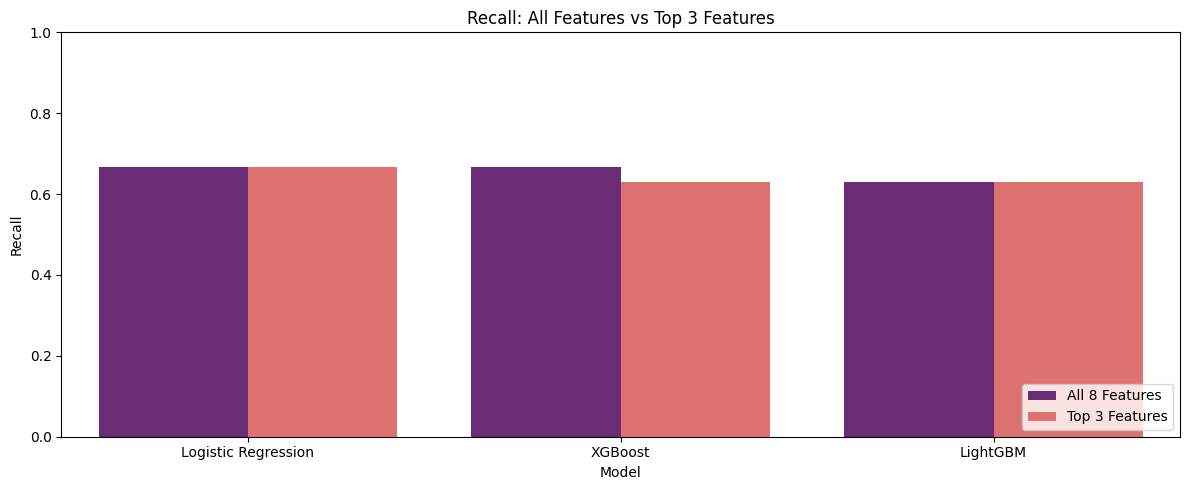

In [41]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_topk,
    x='Model',
    y='Recall',
    hue='Feature Set',
    palette='magma'
)
plt.title('Recall: All Features vs Top 3 Features')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

LightGBM assigned higher importance scores to several key predictive features.
The model focuses on the most informative variables while reducing emphasis on weaker predictors.

Experiment 4

In [42]:
import pandas as pd

pima_df = pd.read_csv('data/raw/diabetes.csv')
diabetes_df = pd.read_csv('data/raw/diabetes_prediction_dataset.csv')
brfss_df = pd.read_csv('data/raw/diabetes_binary_health_indicators_BRFSS2015.csv')

In [43]:
pima_df.columns = pima_df.columns.str.lower()
diabetes_df.columns = diabetes_df.columns.str.lower()
brfss_df.columns = brfss_df.columns.str.lower()

In [44]:
pima_features = set(pima_df.columns) - {'outcome'}
diabetes_features = set(diabetes_df.columns) - {'outcome'}
brfss_features = set(brfss_df.columns) - {'diabetes_binary'}

common_features = list(
    pima_features & diabetes_features & brfss_features
)

print('Common Features:', common_features)

Common Features: ['bmi', 'age']


In [45]:
pima_df.rename(columns={'outcome': 'target'}, inplace=True)
diabetes_df.rename(columns={'outcome': 'target'}, inplace=True)
brfss_df.rename(columns={'diabetes_binary': 'target'}, inplace=True)

In [46]:
pima_df = pima_df[common_features + ['target']]
diabetes_df.rename(columns={'diabetes': 'target'}, inplace=True)
brfss_df = brfss_df[common_features + ['target']]

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def evaluate_transfer(train_df, test_df, train_name, test_name):
    common_features = [col for col in train_df.columns
                       if col != 'target' and col in test_df.columns]

    print(f"Using {len(common_features)} common features: {common_features}\n")

    X_train = train_df[common_features]
    y_train = train_df['target']

    X_test = test_df[common_features]
    y_test = test_df['target']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
    }

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        print(f"{name}")
        print(f"Train: {train_name} → Test: {test_name}")
        print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
        print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
        print('Recall:', round(recall_score(y_test, y_pred, zero_division=0), 4))
        print('F1-score:', round(f1_score(y_test, y_pred, zero_division=0), 4))
        print(' ')

In [48]:
evaluate_transfer(pima_df, diabetes_df, 'Pima', 'diabetes.csv')

evaluate_transfer(pima_df, brfss_df, 'Pima', 'BRFSS')

Using 2 common features: ['bmi', 'age']

Logistic Regression
Train: Pima → Test: diabetes.csv
Accuracy: 0.7261
Precision: 0.2018
Recall: 0.7522
F1-score: 0.3183
 
XGBoost
Train: Pima → Test: diabetes.csv
Accuracy: 0.7267
Precision: 0.141
Recall: 0.4348
F1-score: 0.2129
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: Pima → Test: diabetes.csv
Accuracy: 0.72
Precision: 0.1276
Recall: 0.3929
F1-score: 0.1926
 
Using 2 common features: ['bmi', 'age']

Logistic Regression
Train: Pima → Test: BRFSS
Accuracy: 0.8582
Precision: 0.3333
Recall: 0.018
F1-score: 0.0341
 
XGBoost
Train: Pima → Test: BRFSS
Accuracy: 0.8542
Precision: 0.3341
Recall: 0.0466
F1-score: 0.0818
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: Pima → Test: BRFSS
Accuracy: 0.8541
Precision: 0.336
Recall: 0.0484
F1-score: 0.0845
 


In [49]:
evaluate_transfer(diabetes_df, pima_df, 'diabetes.csv', 'Pima')

evaluate_transfer(diabetes_df, brfss_df, 'diabetes.csv', 'BRFSS')

Using 2 common features: ['age', 'bmi']

Logistic Regression
Train: diabetes.csv → Test: Pima
Accuracy: 0.651
Precision: 0.0
Recall: 0.0
F1-score: 0.0
 
XGBoost
Train: diabetes.csv → Test: Pima
Accuracy: 0.651
Precision: 0.0
Recall: 0.0
F1-score: 0.0
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: diabetes.csv → Test: Pima
Accuracy: 0.651
Precision: 0.0
Recall: 0.0
F1-score: 0.0
 
Using 2 common features: ['age', 'bmi']

Logistic Regression
Train: diabetes.csv → Test: BRFSS
Accuracy: 0.8599
Precision: 0.1511
Recall: 0.0012
F1-score: 0.0024
 
XGBoost
Train: diabetes.csv → Test: BRFSS
Accuracy: 0.8607
Precision: 0.0
Recall: 0.0
F1-score: 0.0
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: diabetes.csv → Test: BRFSS
Accuracy: 0.8607
Precision: 0.0
Recall: 0.0
F1-score: 0.0
 


In [50]:
evaluate_transfer(brfss_df, pima_df, 'BRFSS', 'Pima')

evaluate_transfer(brfss_df, diabetes_df, 'BRFSS', 'diabetes.csv')

Using 2 common features: ['bmi', 'age']

Logistic Regression
Train: BRFSS → Test: Pima
Accuracy: 0.362
Precision: 0.3536
Recall: 1.0
F1-score: 0.5224
 
XGBoost
Train: BRFSS → Test: Pima
Accuracy: 0.651
Precision: 0.5
Recall: 0.0634
F1-score: 0.1126
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: BRFSS → Test: Pima
Accuracy: 0.6641
Precision: 0.9167
Recall: 0.041
F1-score: 0.0786
 
Using 2 common features: ['bmi', 'age']

Logistic Regression
Train: BRFSS → Test: diabetes.csv
Accuracy: 0.2659
Precision: 0.1029
Recall: 0.9894
F1-score: 0.1864
 
XGBoost
Train: BRFSS → Test: diabetes.csv
Accuracy: 0.9068
Precision: 0.2642
Recall: 0.0541
F1-score: 0.0898
 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Train: BRFSS → Test: diabetes.csv
Accuracy: 0.9109
Precision: 0.2848
Recall: 0.0322
F1-score: 0.0579
 
